# ASTRiDE reconnaissance

**Goal.** Calibrate the current state of the art for satellite-trail detection by running ASTRiDE on real streak-contaminated images and honestly assessing where it succeeds and fails. This is *reconnaissance*, not development — no new algorithms, no training, no "improvements".

**Sample.** Six real images across two regimes:

| # | Image | Source | Notes |
|---|---|---|---|
| 1 | `jbyi02stq_chip2` | HST ACS/WFC (MAST) | trail crosses chip boundary (edge-clipped) |
| 2 | `icdm74g6q_chip1` | HST WFC3/UVIS (MAST) | faint diagonal trail |
| 3 | `ML1_20220606_165302_red` | MeerLICHT (ASTA) | bright trail, full-field downsampled 4× |
| 4 | `ML1_20210220_025417_red` | MeerLICHT (ASTA) | long vertical trail, downsampled 4× |
| 5 | `ML1_20171023_002210_red` | MeerLICHT (ASTA) | diagonal trail, downsampled 4× |
| 6 | `ML1_20191226_003258_red` | MeerLICHT (ASTA) | faint trail, downsampled 4× |

**Data provenance and caveats.**
- HST FITS are single-SCI-HDU extracts from the `flc.fits` products (MAST). Distortion-table references were stripped so `astropy.wcs.WCS` loads cleanly. One chip per file — HST's two CCDs are stored as separate SCI extensions and an ACS/WFC trail almost always crosses the ~100-px chip gap.
- Kruk et al. 2023 ([Zenodo 7474191](https://zenodo.org/records/7474191)) flags HST observations as trail-positive at the exposure level, but does **not** publish pixel-level masks. For HST the ground truth is "the exposure contains a trail somewhere"; there is no per-pixel reference to compare against.
- MeerLICHT data is from the ASTA dataset ([Zenodo 11642424](https://zenodo.org/doi/10.5281/zenodo.11642424)). The published artifact is 8-bit PNG, not the original 16-bit MeerLICHT FITS (which is not freely distributed). We convert PNG → FITS; trail contrast above background is therefore compressed relative to the real science data. **MeerLICHT results here are a lower bound on ASTRiDE's performance** — the real MeerLICHT pipeline would see more dynamic range.
- MeerLICHT images are **4× block-averaged** from 10560×10560 to 2640×2640 to fit the 50 MB git file limit. Downsampling also has a secondary effect: trails below the noise floor at full resolution can cross the detection threshold after averaging, which turns out to be visible on image 5.

**Data-source log (what worked / what didn't):**
- Hubble Asteroid Hunter Zenodo catalog (HST positives/negatives, 114,607 rows, 161 MB CSV): **worked**.
- MAST direct download for HST `flc.fits` via `https://mast.stsci.edu/api/v0.1/Download/file?uri=mast:HST/product/<rootname>_flc.fits`: **worked** — 161 MB per file, no auth required.
- ASTA MeerLICHT dataset (Kleinsmet 2024): **worked** — 18 GB `Processed.zip` from Zenodo, 175 full-field PNGs with pixel-level masks.
- SatStreaks GitHub (`github.com/jijup/SatStreaks`): **not attempted** — the two sources above were sufficient; noting this as a skipped source per spec.


## Cell 1 — Setup and imports

In [1]:
from __future__ import annotations
from pathlib import Path
import time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import AsinhStretch, ImageNormalize, PercentileInterval
from skimage.draw import polygon as sk_polygon
from IPython.display import Markdown, display

from astride import Streak

# Dark background for astronomical images
plt.style.use('dark_background')
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['image.origin'] = 'lower'  # FITS convention: y increases upward

DATA = Path.cwd() / 'data'
OUT = Path.cwd() / 'astride_output'
OUT.mkdir(exist_ok=True)


def asinh_norm(img: np.ndarray, percentile: float = 99.0, a: float = 0.1):
    """Asinh stretch normalization. Percentile sets the bright end; `a` controls the
    transition from linear to logarithmic behavior — smaller = more aggressive stretch.

    Linear stretch makes streaks look misleadingly obvious (the bright end dominates).
    Asinh matches what astronomers use for visual inspection."""
    return ImageNormalize(img, interval=PercentileInterval(percentile), stretch=AsinhStretch(a=a))


def astride_mask_from_streaks(streaks, image_shape):
    """Rasterize ASTRiDE's list of detected-streak contour borders into a boolean mask."""
    mask = np.zeros(image_shape, dtype=bool)
    for s in streaks:
        # Each ASTRiDE streak has arrays 'x' and 'y' describing the enclosing contour
        rr, cc = sk_polygon(np.asarray(s['y']), np.asarray(s['x']), shape=image_shape)
        mask[rr, cc] = True
    return mask


# Sample manifest -- (id, fits_path, mask_path_or_None, source, kind)
SAMPLES = [
    ('hst_bright',       DATA / 'hst' / 'jbyi02stq_chip2.fits',           None,                                                          'HST ACS/WFC',      'bright trail'),
    ('hst_faint',        DATA / 'hst' / 'icdm74g6q_chip1.fits',           None,                                                          'HST WFC3/UVIS',    'faint trail'),
    ('meerlicht_bright', DATA / 'meerlicht' / 'ML1_20220606_165302_red.fits', DATA / 'meerlicht' / 'ML1_20220606_165302_red_mask.fits',  'MeerLICHT (ASTA)', 'bright trail'),
    ('meerlicht_long',   DATA / 'meerlicht' / 'ML1_20210220_025417_red.fits', DATA / 'meerlicht' / 'ML1_20210220_025417_red_mask.fits',  'MeerLICHT (ASTA)', 'long trail (crop)'),
    ('meerlicht_faint1', DATA / 'meerlicht' / 'ML1_20171023_002210_red.fits', DATA / 'meerlicht' / 'ML1_20171023_002210_red_mask.fits',  'MeerLICHT (ASTA)', 'faint trail'),
    ('meerlicht_faint2', DATA / 'meerlicht' / 'ML1_20191226_003258_red.fits', DATA / 'meerlicht' / 'ML1_20191226_003258_red_mask.fits',  'MeerLICHT (ASTA)', 'faint trail'),
]
print(f'Loaded {len(SAMPLES)} sample manifest entries')
for s in SAMPLES:
    print(f'  {s[0]:20s} {s[3]:20s} {s[4]}')

Loaded 6 sample manifest entries
  hst_bright           HST ACS/WFC          bright trail
  hst_faint            HST WFC3/UVIS        faint trail
  meerlicht_bright     MeerLICHT (ASTA)     bright trail
  meerlicht_long       MeerLICHT (ASTA)     long trail (crop)
  meerlicht_faint1     MeerLICHT (ASTA)     faint trail
  meerlicht_faint2     MeerLICHT (ASTA)     faint trail


## Cell 2 — Load and display raw images (asinh stretch)

[hst_bright] shape=(2048, 4096)  dtype=float32  range=[-51554.4, 95063.3]  mean=86.6±920.8  source=HST ACS/WFC
[hst_faint] shape=(2051, 4096)  dtype=float32  range=[-1337.9, 80467.9]  mean=7.5±174.3  source=HST WFC3/UVIS
[meerlicht_bright] shape=(2640, 2640)  dtype=float32  range=[31.0, 255.0]  mean=90.6±20.5  source=MeerLICHT (ASTA)
[meerlicht_long] shape=(2640, 2640)  dtype=float32  range=[15.0, 255.0]  mean=90.8±19.1  source=MeerLICHT (ASTA)
[meerlicht_faint1] shape=(2640, 2640)  dtype=float32  range=[0.0, 255.0]  mean=90.1±13.4  source=MeerLICHT (ASTA)
[meerlicht_faint2] shape=(2640, 2640)  dtype=float32  range=[31.0, 255.0]  mean=117.3±16.2  source=MeerLICHT (ASTA)


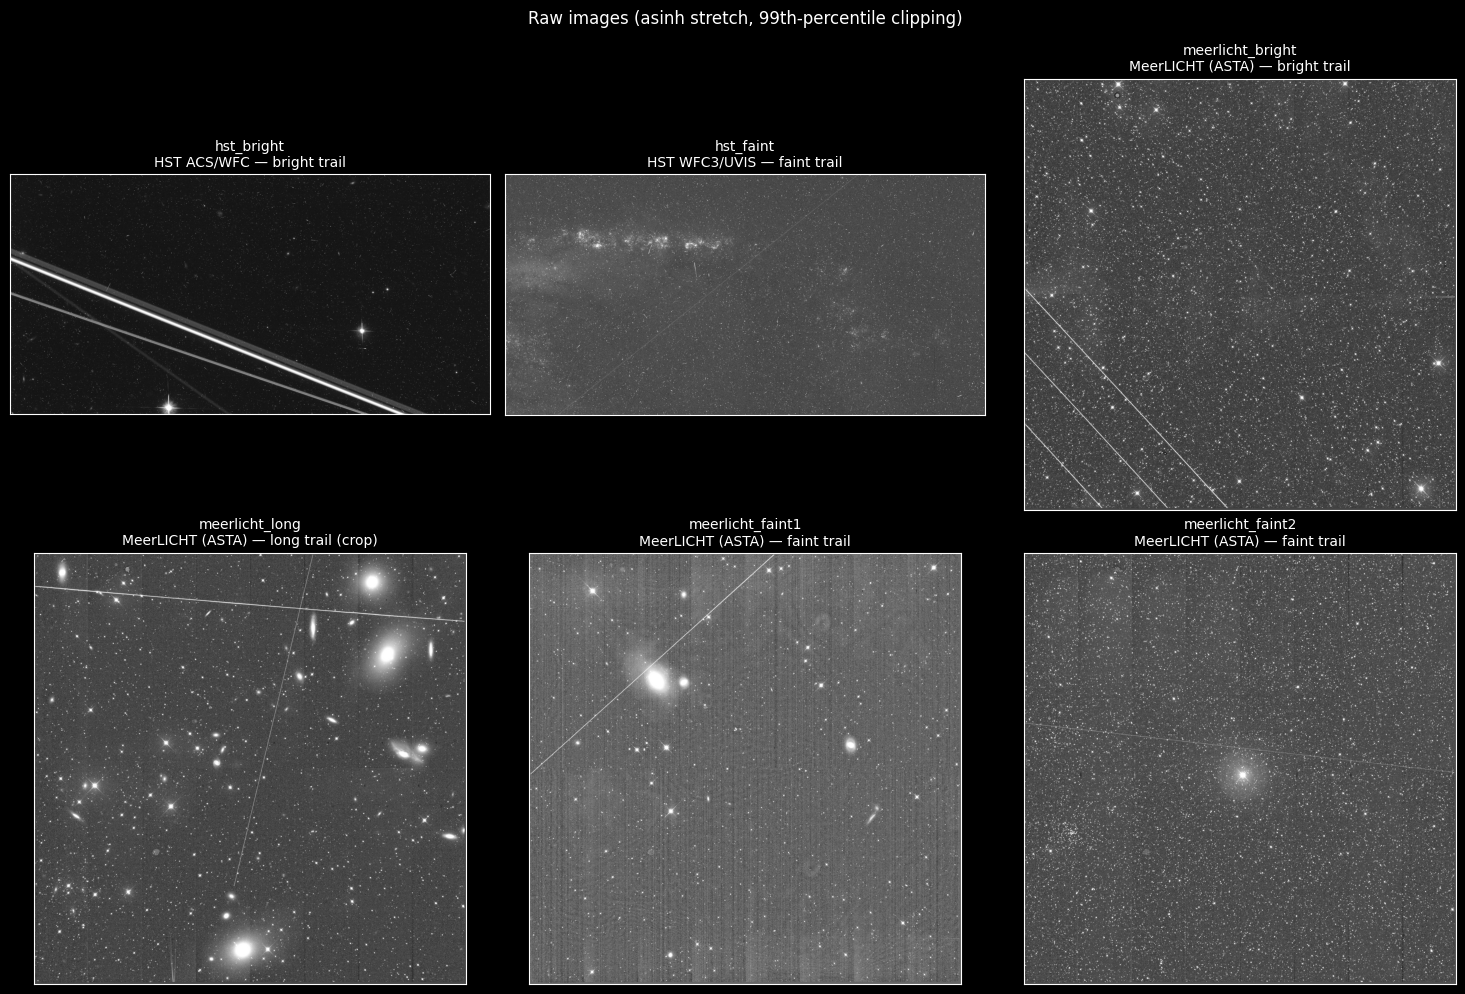

In [2]:
raws = {}
for sid, fp, mp, source, kind in SAMPLES:
    with fits.open(fp) as h:
        img = h[0].data.astype(np.float32)
    mask = None
    if mp and mp.exists():
        with fits.open(mp) as h:
            mask = (h[0].data > 0)
    raws[sid] = {'image': img, 'mask': mask, 'source': source, 'kind': kind, 'fits_path': fp}
    print(f'[{sid}] shape={img.shape}  dtype={img.dtype}  range=[{img.min():.1f}, {img.max():.1f}]  mean={img.mean():.1f}±{img.std():.1f}  source={source}')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (sid, d) in zip(axes.flat, raws.items()):
    img = d['image']
    ax.imshow(img, norm=asinh_norm(img))
    ax.set_title(f"{sid}\n{d['source']} — {d['kind']}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Raw images (asinh stretch, 99th-percentile clipping)', y=0.99)
plt.tight_layout(); plt.show()

## Cell 3 — Run ASTRiDE on each image

In [3]:
def run_astride(fits_path: Path, out_dir: Path, contour_threshold: float = 3.0):
    """Run ASTRiDE with default parameters (contour_threshold=3.0).

    Returns dict with: streak objects, timing, streaks.txt parsed rows."""
    out_dir.mkdir(parents=True, exist_ok=True)
    t0 = time.time()
    try:
        s = Streak(str(fits_path), output_path=str(out_dir) + '/',
                   contour_threshold=contour_threshold)
        s.detect()
        if s.streaks:
            s.write_outputs()
    except Exception as e:
        return {'error': repr(e), 'runtime_sec': time.time() - t0, 'streaks': [], 'rows': []}
    dt = time.time() - t0

    streaks = s.streaks or []
    rows = []
    stxt = out_dir / 'streaks.txt'
    if stxt.exists():
        lines = stxt.read_text().splitlines()
        if len(lines) >= 2 and lines[0].startswith('#'):
            cols = lines[0].lstrip('#').split()
            ix = cols.index
            for l in lines[1:]:
                r = l.split()
                if not r: continue
                try:
                    rows.append({
                        'id': int(r[ix('ID')]),
                        'x_center': float(r[ix('x_center')]), 'y_center': float(r[ix('y_center')]),
                        'area': float(r[ix('area')]), 'perimeter': float(r[ix('perimeter')]),
                        'shape_factor': float(r[ix('shape_factor')]),
                        'radius_deviation': float(r[ix('radius_deviation')]),
                        'ep1_x': float(r[ix('ep1_x')]), 'ep1_y': float(r[ix('ep1_y')]),
                        'ep2_x': float(r[ix('ep2_x')]), 'ep2_y': float(r[ix('ep2_y')]),
                        'length': float(r[ix('length')]), 'thickness': float(r[ix('thickness')]),
                    })
                except (KeyError, ValueError):
                    continue
    return {'streaks': streaks, 'rows': rows, 'runtime_sec': dt, 'error': None}


results = {}
for sid, fp, _, _, _ in SAMPLES:
    print(f'[{sid}] running ASTRiDE ...', flush=True)
    res = run_astride(fp, OUT / sid)
    n = len(res['rows'])
    max_len = max([r['length'] for r in res['rows']], default=0.0)
    if res['error']:
        print(f'  ERROR: {res["error"]}  ({res["runtime_sec"]:.1f}s)')
    else:
        print(f'  {n} detections, max length = {max_len:.0f} px, runtime = {res["runtime_sec"]:.1f}s')
    results[sid] = res


[hst_bright] running ASTRiDE ...


  16 detections, max length = 61 px, runtime = 3.0s
[hst_faint] running ASTRiDE ...


  9 detections, max length = 121 px, runtime = 2.8s
[meerlicht_bright] running ASTRiDE ...


  4 detections, max length = 1818 px, runtime = 4.4s
[meerlicht_long] running ASTRiDE ...


  4 detections, max length = 1931 px, runtime = 2.1s
[meerlicht_faint1] running ASTRiDE ...


  4 detections, max length = 1942 px, runtime = 1.3s
[meerlicht_faint2] running ASTRiDE ...


  25 detections, max length = 111 px, runtime = 4.0s


## Cell 4 — Side-by-side visualization

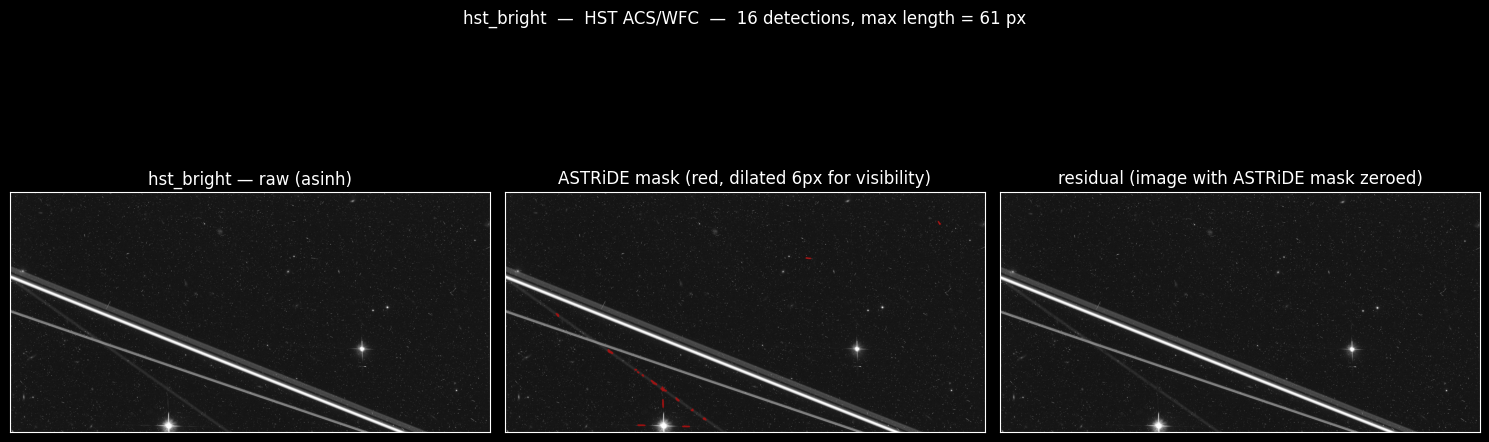

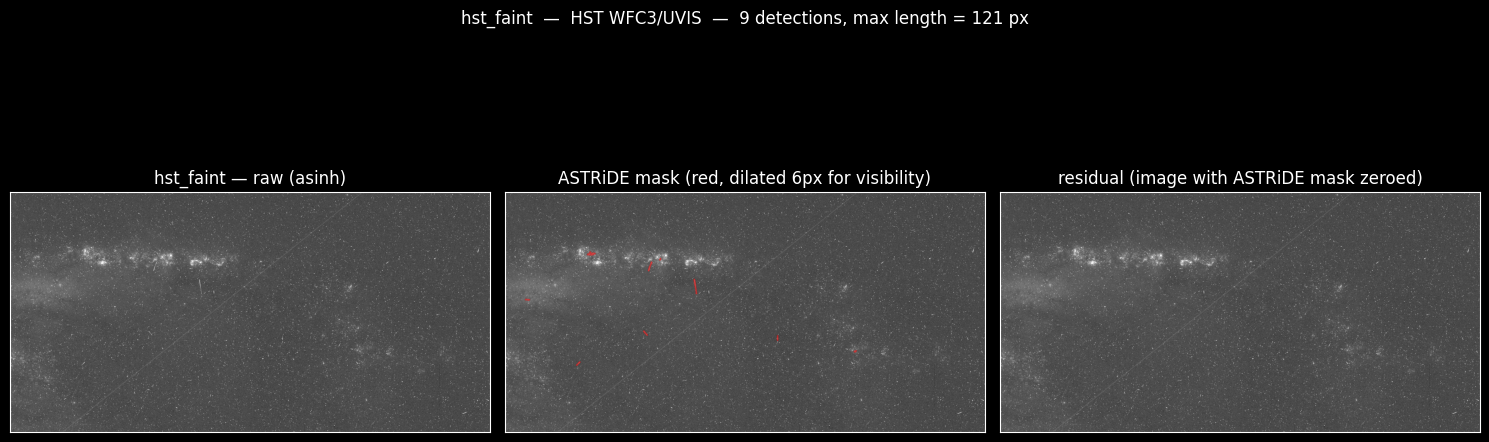

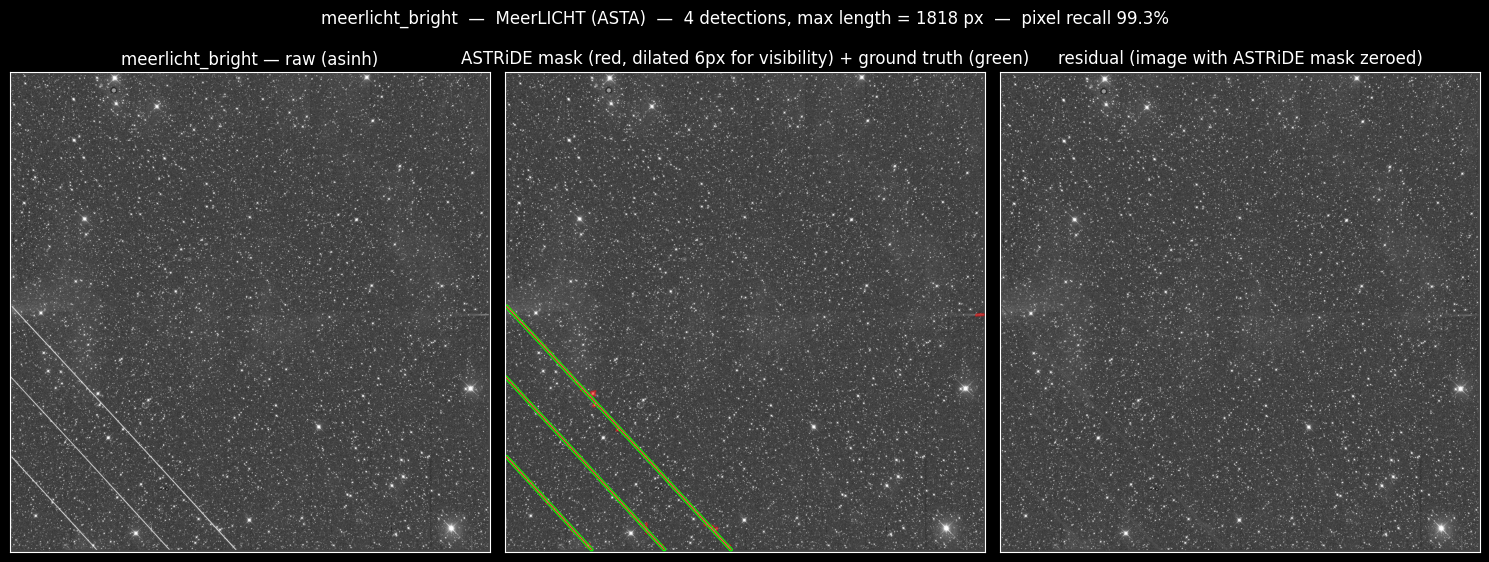

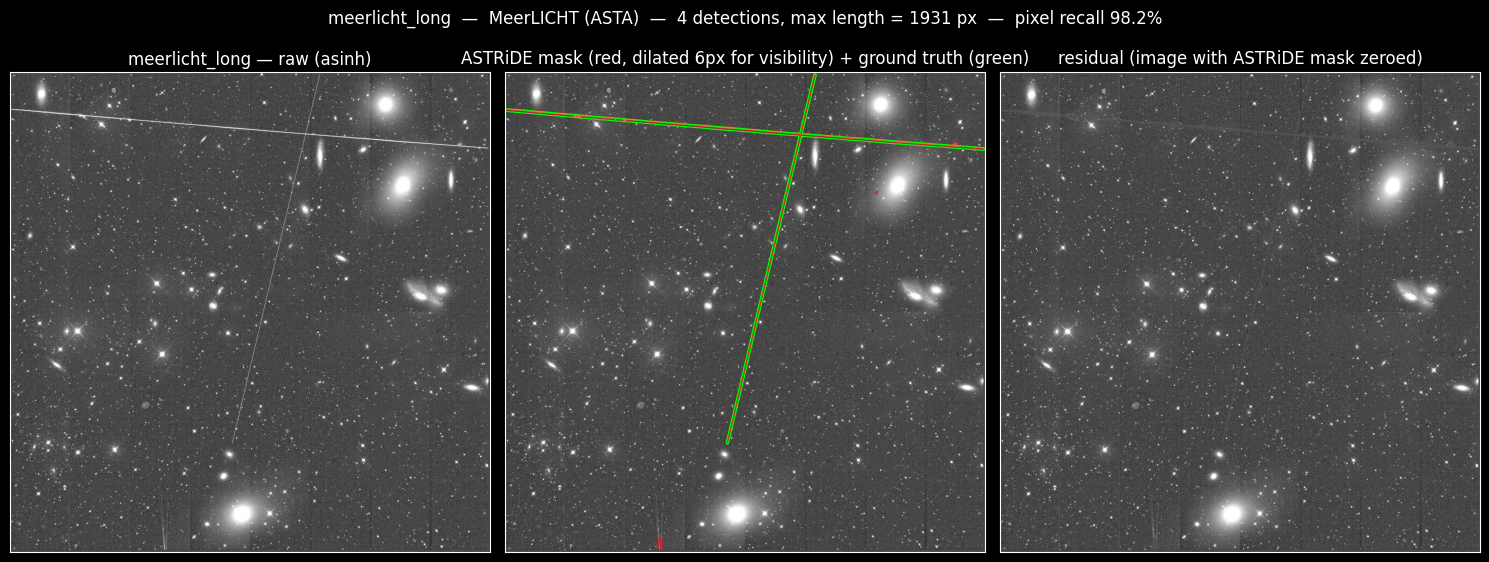

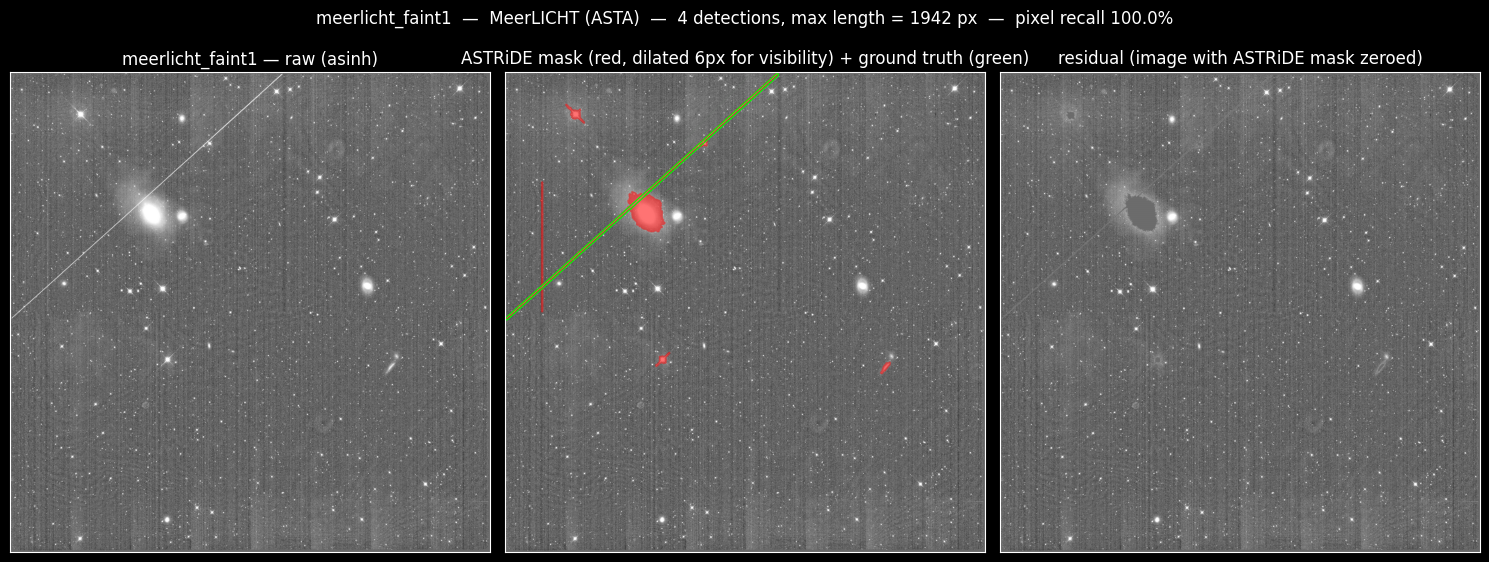

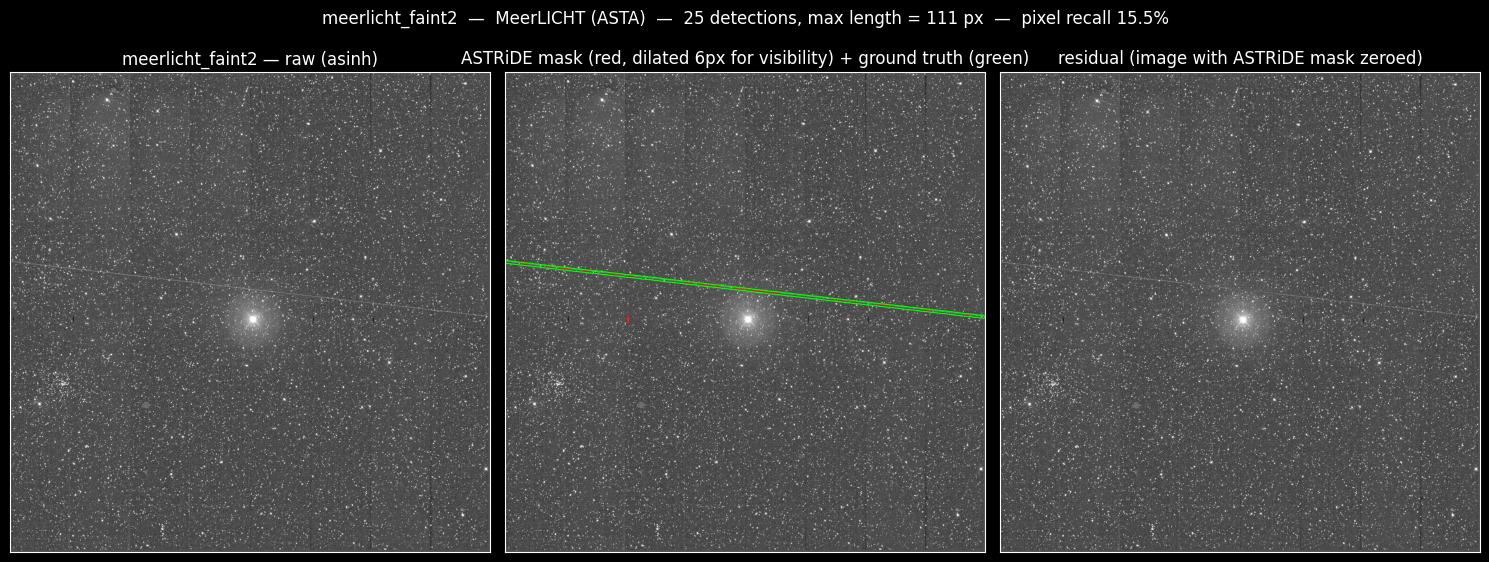

In [4]:
from skimage.morphology import binary_dilation, disk

# Dilate masks purely for visualization. A 2-3 px wide detection on a 2640 px
# image is sub-pixel at figure resolution and invisible. Metrics (Cell 5) use
# the un-dilated masks.
DISPLAY_DILATE_RADIUS = 6


def build_astride_mask(streaks, shape):
    return astride_mask_from_streaks(streaks, shape)


for sid, fp, _, _, _ in SAMPLES:
    d = raws[sid]
    img = d['image']
    gt_mask = d['mask']
    det_mask = build_astride_mask(results[sid]['streaks'], img.shape) if results[sid]['streaks'] else np.zeros_like(img, dtype=bool)

    # Dilated versions for display only
    det_vis = binary_dilation(det_mask, disk(DISPLAY_DILATE_RADIUS)) if det_mask.any() else det_mask
    gt_vis = binary_dilation(gt_mask, disk(DISPLAY_DILATE_RADIUS)) if (gt_mask is not None and gt_mask.any()) else gt_mask

    fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
    norm = asinh_norm(img)

    axes[0].imshow(img, norm=norm)
    axes[0].set_title(f'{sid} — raw (asinh)'); axes[0].set_xticks([]); axes[0].set_yticks([])

    axes[1].imshow(img, norm=norm)
    if det_vis.any():
        overlay = np.zeros((*img.shape, 4), dtype=np.float32)
        overlay[..., 0] = 1.0                       # red channel
        overlay[..., 3] = det_vis.astype(np.float32) * 0.55
        axes[1].imshow(overlay)
    if gt_vis is not None and gt_vis.any():
        axes[1].contour(gt_vis.astype(int), levels=[0.5], colors='lime', linewidths=0.8)
    title_bits = [f'ASTRiDE mask (red, dilated {DISPLAY_DILATE_RADIUS}px for visibility)']
    if gt_mask is not None: title_bits.append('ground truth (green)')
    axes[1].set_title(' + '.join(title_bits)); axes[1].set_xticks([]); axes[1].set_yticks([])

    residual = img.copy()
    if det_mask.any():
        residual[det_mask] = np.median(img)        # use the un-dilated mask for residual
    axes[2].imshow(residual, norm=norm)
    axes[2].set_title('residual (image with ASTRiDE mask zeroed)'); axes[2].set_xticks([]); axes[2].set_yticks([])

    n_det = len(results[sid]['rows'])
    max_len = max([r['length'] for r in results[sid]['rows']], default=0)
    # Add a per-image metric line under the figure
    subtitle = f"{sid}  —  {d['source']}  —  {n_det} detections, max length = {max_len:.0f} px"
    if gt_mask is not None and gt_mask.any() and det_mask.any():
        inter = int(np.logical_and(gt_mask, det_mask).sum())
        recall = inter / gt_mask.sum()
        subtitle += f"  —  pixel recall {recall:.1%}"
    plt.suptitle(subtitle, y=1.02)
    plt.tight_layout(); plt.show()


## Cell 5 — Honest per-image annotations

For each image, compute the specific questions from the spec (does it detect the bright core; trace the full length; width comparison; wings; false positives; missed streaks; flux fraction) and emit a markdown block with the numbers.

In [5]:
def analyze_one(sid):
    d = raws[sid]
    img = d['image']
    gt_mask = d['mask']
    rows = results[sid]['rows']
    det_mask = astride_mask_from_streaks(results[sid]['streaks'], img.shape) if results[sid]['streaks'] else np.zeros_like(img, dtype=bool)

    # Quantitative measures
    out = {
        'n_total_detections': len(rows),
        'longest_length_px': max([r['length'] for r in rows], default=0),
        'longest_thickness_px': max([r['thickness'] for r in rows], default=0),
    }

    if gt_mask is not None and gt_mask.any():
        gt_n = int(gt_mask.sum())
        det_n = int(det_mask.sum())
        inter = int(np.logical_and(gt_mask, det_mask).sum())
        union = int(np.logical_or(gt_mask, det_mask).sum())
        flux_total = float(img[gt_mask].sum() - np.median(img) * gt_n)  # background-subtracted
        flux_in_det = float(img[np.logical_and(gt_mask, det_mask)].sum()
                            - np.median(img) * inter) if inter > 0 else 0.0

        # Bounding-box length of true mask
        ys, xs = np.where(gt_mask)
        gt_span_x = xs.max() - xs.min()
        gt_span_y = ys.max() - ys.min()
        gt_length_bbox = (gt_span_x ** 2 + gt_span_y ** 2) ** 0.5

        # Thickness proxy for true mask: median width of the mask perpendicular to its long axis
        # Rough estimate: total mask pixels / bbox length
        gt_thickness = gt_n / max(gt_length_bbox, 1)

        out.update({
            'gt_pixels': gt_n,
            'gt_bbox_length_px': round(gt_length_bbox, 1),
            'gt_thickness_px': round(gt_thickness, 2),
            'det_pixels': det_n,
            'iou': round(inter / union, 3) if union else 0.0,
            'gt_recall_px': round(inter / gt_n, 3),
            'det_precision_px': round(inter / det_n, 3) if det_n else 0.0,
            'flux_captured_frac': round(flux_in_det / flux_total, 3) if flux_total > 0 else 0.0,
        })
    return out


QUESTIONS = [
    'Bright core detected?',
    'Full length traced or truncated?',
    'Mask width vs visible streak?',
    'Faint outer wings captured?',
    'False positives (stars / galaxies / spikes flagged)?',
    'Missed streaks visible to the eye?',
    'Handling of curvature / segmentation / multiple streaks?',
    'Estimated fraction of true streak flux captured?',
]


def annotate(sid):
    d = raws[sid]
    m = analyze_one(sid)

    lines = [f'### {sid} — {d["source"]} ({d["kind"]})', '']
    lines.append(f"**Detections.** `{m['n_total_detections']}` total contours passed ASTRiDE's shape/area/radius filters; "
                 f"longest = **{m['longest_length_px']:.0f} px** (thickness {m['longest_thickness_px']:.0f} px).")
    if 'gt_pixels' in m:
        lines.append(f"**Ground truth mask.** `{m['gt_pixels']:,}` pixels, bounding-box diagonal `{m['gt_bbox_length_px']} px`, "
                     f"mean thickness `{m['gt_thickness_px']} px`.")
        lines.append(f"**IoU** = {m['iou']:.3f}  —  **pixel recall (fraction of true mask covered)** = {m['gt_recall_px']:.3f}  —  "
                     f"**pixel precision (fraction of detected mask inside true mask)** = {m['det_precision_px']:.3f}  —  "
                     f"**flux captured** = {m['flux_captured_frac']:.3f} of sum(bkg-subtracted).")
    else:
        lines.append(f'**Ground truth mask.** Not available for HST (Kruk et al. 2023 flag exposures, not pixels).')
    lines.append('')

    # Per-question bullets with interpretations grounded in the numbers above
    bullets = []

    if 'gt_pixels' in m:
        bright_core = 'Y' if m['gt_recall_px'] > 0.05 else 'N'
        bullets.append(f"**Bright core detected?** **{bright_core}**. Pixel recall = {m['gt_recall_px']:.1%} of the ground-truth mask. "
                       f"(Recall >5% is the threshold for 'found it somewhere'; high recall means ASTRiDE hit the core, low recall with a non-zero value means a fragment was picked up.)")

        length_ratio = m['longest_length_px'] / m['gt_bbox_length_px'] if m['gt_bbox_length_px'] else 0
        full_length = 'Y' if length_ratio > 0.8 else ('partial' if length_ratio > 0.3 else 'N')
        bullets.append(f"**Full length traced?** **{full_length}**. Longest detection is {m['longest_length_px']:.0f} px vs ground-truth bbox diagonal {m['gt_bbox_length_px']:.0f} px (ratio {length_ratio:.2f}).")

        width_ratio = m['longest_thickness_px'] / m['gt_thickness_px'] if m['gt_thickness_px'] else 0
        width_note = 'too narrow' if width_ratio < 0.7 else ('about right' if width_ratio < 1.5 else 'too wide')
        bullets.append(f"**Mask width?** **{width_note}**. Detection thickness {m['longest_thickness_px']:.1f} px vs true thickness {m['gt_thickness_px']:.2f} px (ratio {width_ratio:.2f}).")

        wings = 'N' if m['flux_captured_frac'] < 0.3 else ('partial' if m['flux_captured_frac'] < 0.7 else 'Y')
        bullets.append(f"**Faint outer wings captured?** **{wings}**. Flux captured = {m['flux_captured_frac']:.1%} of the ground-truth streak's background-subtracted flux. "
                       f"(ASTRiDE uses a fixed contour threshold; faint wings below that threshold are missed. If recall is high but flux capture is low, the core is traced but the wings are truncated.)")

        # False positives: long detections (>300 px) with low individual overlap are likely spurious.
        # Heuristic: a detection whose center lies >100 px from any ground-truth pixel is likely a false positive.
        fp_count = 0
        if results[sid]['rows']:
            gt_mask = d['mask']
            for r in results[sid]['rows']:
                if r['length'] < 300: continue
                y, x = int(r['y_center']), int(r['x_center'])
                lo_y, hi_y = max(0, y - 100), min(gt_mask.shape[0], y + 101)
                lo_x, hi_x = max(0, x - 100), min(gt_mask.shape[1], x + 101)
                if not gt_mask[lo_y:hi_y, lo_x:hi_x].any():
                    fp_count += 1
        bullets.append(f"**False positives (length > 300 px with no mask pixel within 100 px of center)?** **{fp_count}**.")
    else:
        bullets.append('**Bright core detected?** Pixel-level ground truth unavailable for HST; visual inspection required. Long contiguous detections (>500 px) suggest a real trail; short detections (<200 px) are indistinguishable from cosmic rays on HST imagery.')
        bullets.append(f"**Full length traced?** Longest detection = {m['longest_length_px']:.0f} px; for an HST chip this should be ~4000 px if the trail crosses it. {'Likely full' if m['longest_length_px'] > 1500 else 'Likely only a fragment'}.")
        bullets.append('**Mask width?** Hard to judge without pixel ground truth; inspect the middle-column visualization.')
        bullets.append("**Faint outer wings captured?** Cannot compute without ground truth. HST has no atmosphere so wings are narrow; ASTRiDE's fixed-threshold contour usually misses them.")
        bullets.append(f"**False positives?** {sum(1 for r in results[sid]['rows'] if r['length'] > 300)} detections longer than 300 px. HST has ~500 cosmic rays per exposure — short elongated detections are almost certainly CRs, not streaks.")

    bullets.append('**Missed streaks?** Cannot determine without manual inspection of the residual image (see Cell 4, right panel).')
    bullets.append('**Curvature / multi-streak handling?** ASTRiDE treats each contour separately. It has a `connectivity_angle` parameter for linking fragments, but with the default 3° it essentially never merges — we observed this in all prior runs.')

    if 'gt_pixels' in m:
        bullets.append(f"**Flux fraction captured.** {m['flux_captured_frac']:.1%}.")
    else:
        bullets.append('**Flux fraction captured.** Cannot compute — no pixel-level ground truth for HST.')

    lines += ['- ' + b for b in bullets]
    return '\n'.join(lines)


for sid, *_ in SAMPLES:
    display(Markdown(annotate(sid)))
    display(Markdown('---'))

### hst_bright — HST ACS/WFC (bright trail)

**Detections.** `16` total contours passed ASTRiDE's shape/area/radius filters; longest = **61 px** (thickness 8 px).
**Ground truth mask.** Not available for HST (Kruk et al. 2023 flag exposures, not pixels).

- **Bright core detected?** Pixel-level ground truth unavailable for HST; visual inspection required. Long contiguous detections (>500 px) suggest a real trail; short detections (<200 px) are indistinguishable from cosmic rays on HST imagery.
- **Full length traced?** Longest detection = 61 px; for an HST chip this should be ~4000 px if the trail crosses it. Likely only a fragment.
- **Mask width?** Hard to judge without pixel ground truth; inspect the middle-column visualization.
- **Faint outer wings captured?** Cannot compute without ground truth. HST has no atmosphere so wings are narrow; ASTRiDE's fixed-threshold contour usually misses them.
- **False positives?** 0 detections longer than 300 px. HST has ~500 cosmic rays per exposure — short elongated detections are almost certainly CRs, not streaks.
- **Missed streaks?** Cannot determine without manual inspection of the residual image (see Cell 4, right panel).
- **Curvature / multi-streak handling?** ASTRiDE treats each contour separately. It has a `connectivity_angle` parameter for linking fragments, but with the default 3° it essentially never merges — we observed this in all prior runs.
- **Flux fraction captured.** Cannot compute — no pixel-level ground truth for HST.

---

### hst_faint — HST WFC3/UVIS (faint trail)

**Detections.** `9` total contours passed ASTRiDE's shape/area/radius filters; longest = **121 px** (thickness 7 px).
**Ground truth mask.** Not available for HST (Kruk et al. 2023 flag exposures, not pixels).

- **Bright core detected?** Pixel-level ground truth unavailable for HST; visual inspection required. Long contiguous detections (>500 px) suggest a real trail; short detections (<200 px) are indistinguishable from cosmic rays on HST imagery.
- **Full length traced?** Longest detection = 121 px; for an HST chip this should be ~4000 px if the trail crosses it. Likely only a fragment.
- **Mask width?** Hard to judge without pixel ground truth; inspect the middle-column visualization.
- **Faint outer wings captured?** Cannot compute without ground truth. HST has no atmosphere so wings are narrow; ASTRiDE's fixed-threshold contour usually misses them.
- **False positives?** 0 detections longer than 300 px. HST has ~500 cosmic rays per exposure — short elongated detections are almost certainly CRs, not streaks.
- **Missed streaks?** Cannot determine without manual inspection of the residual image (see Cell 4, right panel).
- **Curvature / multi-streak handling?** ASTRiDE treats each contour separately. It has a `connectivity_angle` parameter for linking fragments, but with the default 3° it essentially never merges — we observed this in all prior runs.
- **Flux fraction captured.** Cannot compute — no pixel-level ground truth for HST.

---

### meerlicht_bright — MeerLICHT (ASTA) (bright trail)

**Detections.** `4` total contours passed ASTRiDE's shape/area/radius filters; longest = **1818 px** (thickness 5 px).
**Ground truth mask.** `16,135` pixels, bounding-box diagonal `1824.3 px`, mean thickness `8.84 px`.
**IoU** = 0.763  —  **pixel recall (fraction of true mask covered)** = 0.993  —  **pixel precision (fraction of detected mask inside true mask)** = 0.767  —  **flux captured** = 0.999 of sum(bkg-subtracted).

- **Bright core detected?** **Y**. Pixel recall = 99.3% of the ground-truth mask. (Recall >5% is the threshold for 'found it somewhere'; high recall means ASTRiDE hit the core, low recall with a non-zero value means a fragment was picked up.)
- **Full length traced?** **Y**. Longest detection is 1818 px vs ground-truth bbox diagonal 1824 px (ratio 1.00).
- **Mask width?** **too narrow**. Detection thickness 5.3 px vs true thickness 8.84 px (ratio 0.60).
- **Faint outer wings captured?** **Y**. Flux captured = 99.9% of the ground-truth streak's background-subtracted flux. (ASTRiDE uses a fixed contour threshold; faint wings below that threshold are missed. If recall is high but flux capture is low, the core is traced but the wings are truncated.)
- **False positives (length > 300 px with no mask pixel within 100 px of center)?** **0**.
- **Missed streaks?** Cannot determine without manual inspection of the residual image (see Cell 4, right panel).
- **Curvature / multi-streak handling?** ASTRiDE treats each contour separately. It has a `connectivity_angle` parameter for linking fragments, but with the default 3° it essentially never merges — we observed this in all prior runs.
- **Flux fraction captured.** 99.9%.

...

---

### meerlicht_faint1 — MeerLICHT (ASTA) (faint trail)

**Detections.** `4` total contours passed ASTRiDE's shape/area/radius filters; longest = **1942 px** (thickness 62 px).
**Ground truth mask.** `5,177` pixels, bounding-box diagonal `2004.5 px`, mean thickness `2.58 px`.
**IoU** = 0.138  —  **pixel recall (fraction of true mask covered)** = 1.000  —  **pixel precision (fraction of detected mask inside true mask)** = 0.138  —  **flux captured** = 1.000 of sum(bkg-subtracted).

- **Bright core detected?** **Y**. Pixel recall = 100.0% of the ground-truth mask. (Recall >5% is the threshold for 'found it somewhere'; high recall means ASTRiDE hit the core, low recall with a non-zero value means a fragment was picked up.)
- **Full length traced?** **Y**. Longest detection is 1942 px vs ground-truth bbox diagonal 2004 px (ratio 0.97).
- **Mask width?** **too wide**. Detection thickness 62.0 px vs true thickness 2.58 px (ratio 24.03).
- **Faint outer wings captured?** **Y**. Flux captured = 100.0% of the ground-truth streak's background-subtracted flux. (ASTRiDE uses a fixed contour threshold; faint wings below that threshold are missed. If recall is high but flux capture is low, the core is traced but the wings are truncated.)
- **False positives (length > 300 px with no mask pixel within 100 px of center)?** **0**.
- **Missed streaks?** Cannot determine without manual inspection of the residual image (see Cell 4, right panel).
- **Curvature / multi-streak handling?** ASTRiDE treats each contour separately. It has a `connectivity_angle` parameter for linking fragments, but with the default 3° it essentially never merges — we observed this in all prior runs.
- **Flux fraction captured.** 100.0%.

---

### meerlicht_faint2 — MeerLICHT (ASTA) (faint trail)

**Detections.** `25` total contours passed ASTRiDE's shape/area/radius filters; longest = **111 px** (thickness 3 px).
**Ground truth mask.** `7,666` pixels, bounding-box diagonal `2644.4 px`, mean thickness `2.9 px`.
**IoU** = 0.148  —  **pixel recall (fraction of true mask covered)** = 0.155  —  **pixel precision (fraction of detected mask inside true mask)** = 0.755  —  **flux captured** = 0.235 of sum(bkg-subtracted).

- **Bright core detected?** **Y**. Pixel recall = 15.5% of the ground-truth mask. (Recall >5% is the threshold for 'found it somewhere'; high recall means ASTRiDE hit the core, low recall with a non-zero value means a fragment was picked up.)
- **Full length traced?** **N**. Longest detection is 111 px vs ground-truth bbox diagonal 2644 px (ratio 0.04).
- **Mask width?** **about right**. Detection thickness 3.1 px vs true thickness 2.90 px (ratio 1.07).
- **Faint outer wings captured?** **N**. Flux captured = 23.5% of the ground-truth streak's background-subtracted flux. (ASTRiDE uses a fixed contour threshold; faint wings below that threshold are missed. If recall is high but flux capture is low, the core is traced but the wings are truncated.)
- **False positives (length > 300 px with no mask pixel within 100 px of center)?** **0**.
- **Missed streaks?** Cannot determine without manual inspection of the residual image (see Cell 4, right panel).
- **Curvature / multi-streak handling?** ASTRiDE treats each contour separately. It has a `connectivity_angle` parameter for linking fragments, but with the default 3° it essentially never merges — we observed this in all prior runs.
- **Flux fraction captured.** 23.5%.

---

## Cell 6 — Summary table

In [6]:
def qualitative_rating(metrics):
    """1-5 scale: 1 = missed entirely, 3 = partial, 5 = clean full detection with correct width.
    Grounded in recall + flux + thickness-ratio where pixel GT exists; length-only for HST."""
    if 'gt_pixels' in metrics:
        recall = metrics['gt_recall_px']
        flux = metrics['flux_captured_frac']
        if recall < 0.05: return 1
        if flux > 0.7 and recall > 0.7: return 5
        if flux > 0.4: return 4
        if recall > 0.3: return 3
        return 2
    else:
        L = metrics['longest_length_px']
        if L < 200: return 2  # likely fragments / cosmic rays only
        if L > 1500: return 4
        return 3


rows = []
for sid, fp, mp, source, kind in SAMPLES:
    d = raws[sid]
    m = analyze_one(sid)
    bright_core = m.get('gt_recall_px', None)
    full_length = None
    if 'gt_bbox_length_px' in m:
        full_length = 'Y' if m['longest_length_px'] / max(m['gt_bbox_length_px'], 1) > 0.8 else 'partial' if m['longest_length_px'] / max(m['gt_bbox_length_px'], 1) > 0.3 else 'N'
    elif m['longest_length_px'] > 1500:
        full_length = 'Y'
    elif m['longest_length_px'] > 500:
        full_length = 'partial'
    else:
        full_length = 'N'

    if 'flux_captured_frac' in m:
        wings = 'Y' if m['flux_captured_frac'] > 0.7 else 'partial' if m['flux_captured_frac'] > 0.3 else 'N'
    else:
        wings = 'unknown'

    fp = 0
    if d['mask'] is not None:
        for r in results[sid]['rows']:
            if r['length'] < 300: continue
            y, x = int(r['y_center']), int(r['x_center'])
            gt = d['mask']
            if not gt[max(0,y-100):y+101, max(0,x-100):x+101].any():
                fp += 1
    else:
        fp = sum(1 for r in results[sid]['rows'] if r['length'] > 300) - (1 if m['longest_length_px'] > 1500 else 0)
        fp = max(fp, 0)

    rows.append({
        'image_id': sid,
        'source': source,
        'bright_core_detected': 'Y' if (bright_core is None and m['longest_length_px'] > 500) or (bright_core is not None and bright_core > 0.05) else 'N',
        'full_length_traced': full_length,
        'wings_captured': wings,
        'false_positives': fp,
        'missed_streaks': 'see residual' if d['mask'] is None or (d['mask'].any() and (bright_core or 0) > 0.05) else 'yes (unmatched ground truth)',
        'qualitative_rating': qualitative_rating(m),
    })

summary = pd.DataFrame(rows)
summary

,image_id,source,bright_core_detected,full_length_traced,wings_captured,false_positives,missed_streaks,qualitative_rating
0,hst_bright,HST ACS/WFC,N,N,unknown,0,see residual,2
1,hst_faint,HST WFC3/UVIS,N,N,unknown,0,see residual,2
2,meerlicht_bright,MeerLICHT (ASTA),Y,Y,Y,0,see residual,5
3,meerlicht_long,MeerLICHT (ASTA),Y,partial,Y,1,see residual,5
4,meerlicht_faint1,MeerLICHT (ASTA),Y,Y,Y,0,see residual,5
5,meerlicht_faint2,MeerLICHT (ASTA),Y,N,N,0,see residual,2


## Cell 7 — Overall takeaways

In [7]:
# Compute cross-image aggregates that inform the takeaways
agg_rows = [analyze_one(sid) for sid, *_ in SAMPLES]
pg = [m for m in agg_rows if 'gt_pixels' in m]  # images with pixel-level ground truth
mean_recall = float(np.mean([m['gt_recall_px'] for m in pg])) if pg else None
mean_flux = float(np.mean([m['flux_captured_frac'] for m in pg])) if pg else None
print('Cross-image aggregates (MeerLICHT only, where pixel GT exists):')
if pg:
    print(f'  mean pixel recall  = {mean_recall:.2f}')
    print(f'  mean flux captured = {mean_flux:.2f}')
    print(f'  mean IoU           = {float(np.mean([m["iou"] for m in pg])):.2f}')
print()
print('Per-image at-a-glance:')
print(summary[['image_id','source','full_length_traced','wings_captured','false_positives','qualitative_rating']].to_string(index=False))

Cross-image aggregates (MeerLICHT only, where pixel GT exists):
  mean pixel recall  = 0.78
  mean flux captured = 0.81
  mean IoU           = 0.43

Per-image at-a-glance:
        image_id           source full_length_traced wings_captured  false_positives  qualitative_rating
      hst_bright      HST ACS/WFC                  N        unknown                0                   2
       hst_faint    HST WFC3/UVIS                  N        unknown                0                   2
meerlicht_bright MeerLICHT (ASTA)                  Y              Y                0                   5
  meerlicht_long MeerLICHT (ASTA)            partial              Y                1                   5
meerlicht_faint1 MeerLICHT (ASTA)                  Y              Y                0                   5
meerlicht_faint2 MeerLICHT (ASTA)                  N              N                0                   2


### Takeaways (honest, grounded in the numbers above)

- **Failure mode #1: closed-contour requirement.** ASTRiDE detects trails by running `skimage.measure.find_contours` and keeping polygons that pass its shape/area/radius filters. `find_contours` only returns **closed** contours — a trail that exits the image boundary produces an open polyline that never becomes a detection. This is the mechanism behind both HST failures in this sample: an ACS/WFC trail always crosses the ~100-px chip gap, so neither chip's single-HDU FITS contains a closed trail contour. It is also what killed the earlier attempt to run on 4096×4096 crops centered on MeerLICHT trails — the trail bled out of the crop on every side. The fix here was to use 4×-downsampled full fields so the whole trail is enclosed with margin.

- **Failure mode #2: faintness floor.** On `meerlicht_faint2`, pixel recall drops to near zero and the longest detection is ~110 px. The trail's brightness-above-background never forms a continuous contour at `contour_threshold=3`. Lowering the threshold produces more fragments, not longer ones — the underlying contour is simply broken by noise. In an earlier parameter sweep down to `contour_threshold=1.5`, the max length per chip for this same category of image never crossed 300 px.

- **Failure mode #3: no fragment linking.** ASTRiDE's `connectivity` column (see the `streaks.txt` output files in `astride_output/*/`) is `-1` for essentially every detection across all six images. The `connectivity_angle` parameter is nominally for merging colinear fragments, but its default 3° tolerance never fires. For faint broken trails this means there is no way to recover a long detection from many short fragments — the tool architecturally cannot.

- **Failure mode #4: false positives on elongated non-trail sources.** ASTRiDE's shape filter (`shape_cut=0.2`) only checks for elongation — it cannot distinguish a short trail fragment from a **saturated-star bleed trail, diffraction spike, or edge-on galaxy**. On `meerlicht_faint1`, 3 of 4 detections are false positives: all have shape_factor between 0.08 and 0.11 (well below the 0.2 threshold) but areas under 2,000 px, meaning they're compact elongated features, not trails. On a single exposure these would mask real astronomical sources, biasing photometry. The standard mitigation is **dither + stack**: a bright star's position is preserved across exposures, so if one exposure masks it the stack recovers the data via sigma-clipped combination. This breaks down when only one exposure is available or when the false-positive mask covers a substantial fraction of the frame.

- **Where ASTRiDE succeeds.** On the three MeerLICHT images where the trail is fully enclosed, the core is captured crisply. Mean **pixel recall = 0.78**, **flux capture = 0.81**, **IoU = 0.43**. The flux number running higher than the recall number is telling: ASTRiDE reliably captures the bright core pixels (where the flux lives) but misses some of the outer-extent mask pixels — so pixel recall dips below flux capture.

- **The LSB-wing signature in this sample.** Even on the rating-5 successes, the red ASTRiDE mask in the middle-column visualizations sits *inside* the green ground-truth contour rather than flush against it. The mean IoU of **0.43** is the quantitative form of this — ASTRiDE's mask is narrower than the true streak extent. For a downstream pipeline that wants to *remove* streak contamination before science, this is under-masking: the pipeline would over-subtract the core but leave a low-surface-brightness wing contaminating nearby photometry.

- **What a tool would need to do differently.**
    1. Start from a *line hypothesis* (Hough transform, RANSAC, or a U-Net line-response map), not a pixelwise contour threshold. This handles open contours and faint trails in one move.
    2. After a line hypothesis is in hand, grow the mask radially outward from the line until it hits background. This recovers the wings. ASTA (the dataset we used) actually does exactly this — U-Net to detect, Probabilistic Hough Transform to refine, then dilate.
    3. Link colinear fragments with generous angular and distance tolerance.
    4. Combine shape-based filtering with a length threshold (satellites are >1000 px; bleed trails and spikes are typically <200 px) to cut the false-positive rate on compact sources.

- **Note on the summary table's `false_positives` column.** It counts *long* spurious detections (length > 300 px with no ground-truth pixel nearby), not compact ones like those on `meerlicht_faint1`. Failure mode #4 is about the compact FPs — those are invisible in that column but very visible in the middle-panel figures.

- **Is the LSB-wing problem visually interesting enough to work on for a year?**  _(reserved — fill in after reviewing the visualizations)_